In [1]:
import os
import sys
import json
import glob
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
sys.path.append("..")
from process.ifc_analysis_utils import *

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
from utils.common import DATASETS, CLASSIFIERS, BASELINE_METHODS
from process.ifc_tables import *

root = Path.cwd().parent
mixs = ["mix_37_235", "mix_55_532"]
metrics = ["F1_score", "G_mean"]

all_results = build_all_results(data_root= root/"experiments")

artifacts_table = build_artifacts_path_table(data_root=root/"experiments")
orig_table = build_original_data_path_table(data_root=root/"experiments")
orig_table = add_pos_paths(orig_table, pos_label=1)

✅ build_all_results 完成: 共11625行, baseline=3255, none=930, self_loop=7440


### 1. 分类结果展示

In [ ]:
vae_only_summary = summarize_method_stats(all_results, "none_noft")
raw_table = build_raw_reference_table(all_results, DATASETS, CLASSIFIERS)

extra_rows = [
    ("VAE-only (none\\_noft)", "none_noft", None, None),
    ("VAE+FT (none\\_ft)",     "none_ft",   None, None),
    ("IFC (smote\\_ft)",       "smote_ft",  "mix_55_532", 3),
]

main_table = build_comparison_table(
    all_results, extra_rows, DATASETS, CLASSIFIERS,
    baseline_methods=sorted(BASELINE_METHODS - {"raw"}),
    mark_close_calls=True,
)

print(raw_table)
print(main_table)

### 2. TSNE可视化

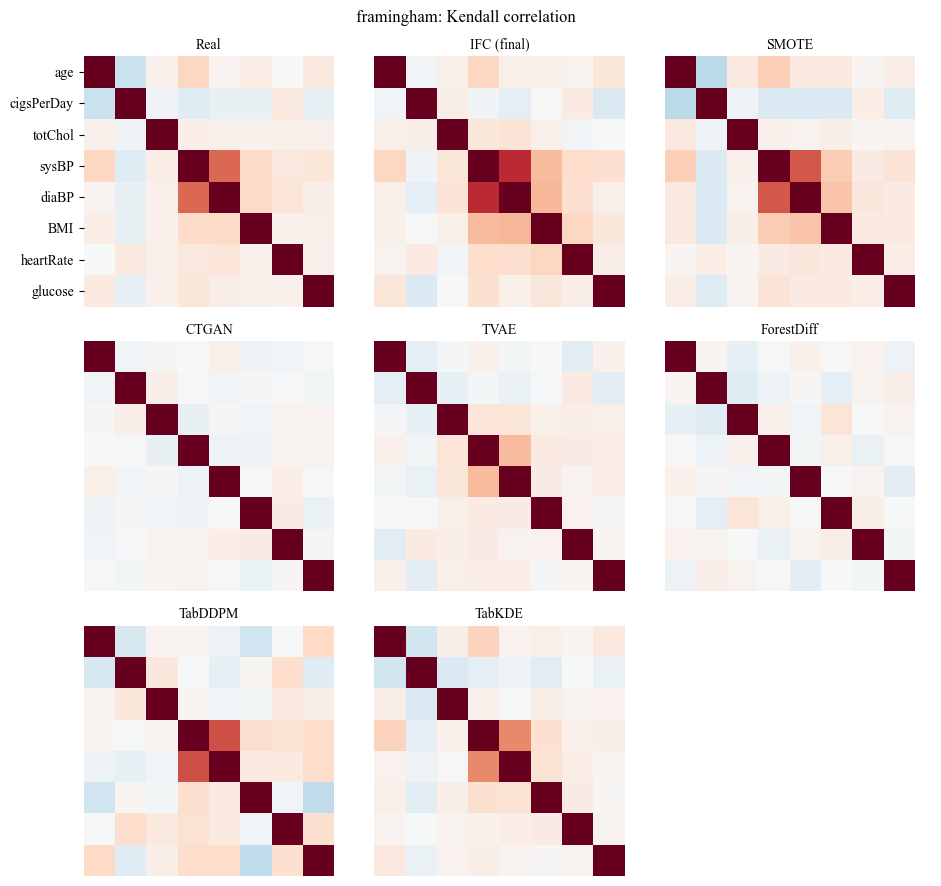

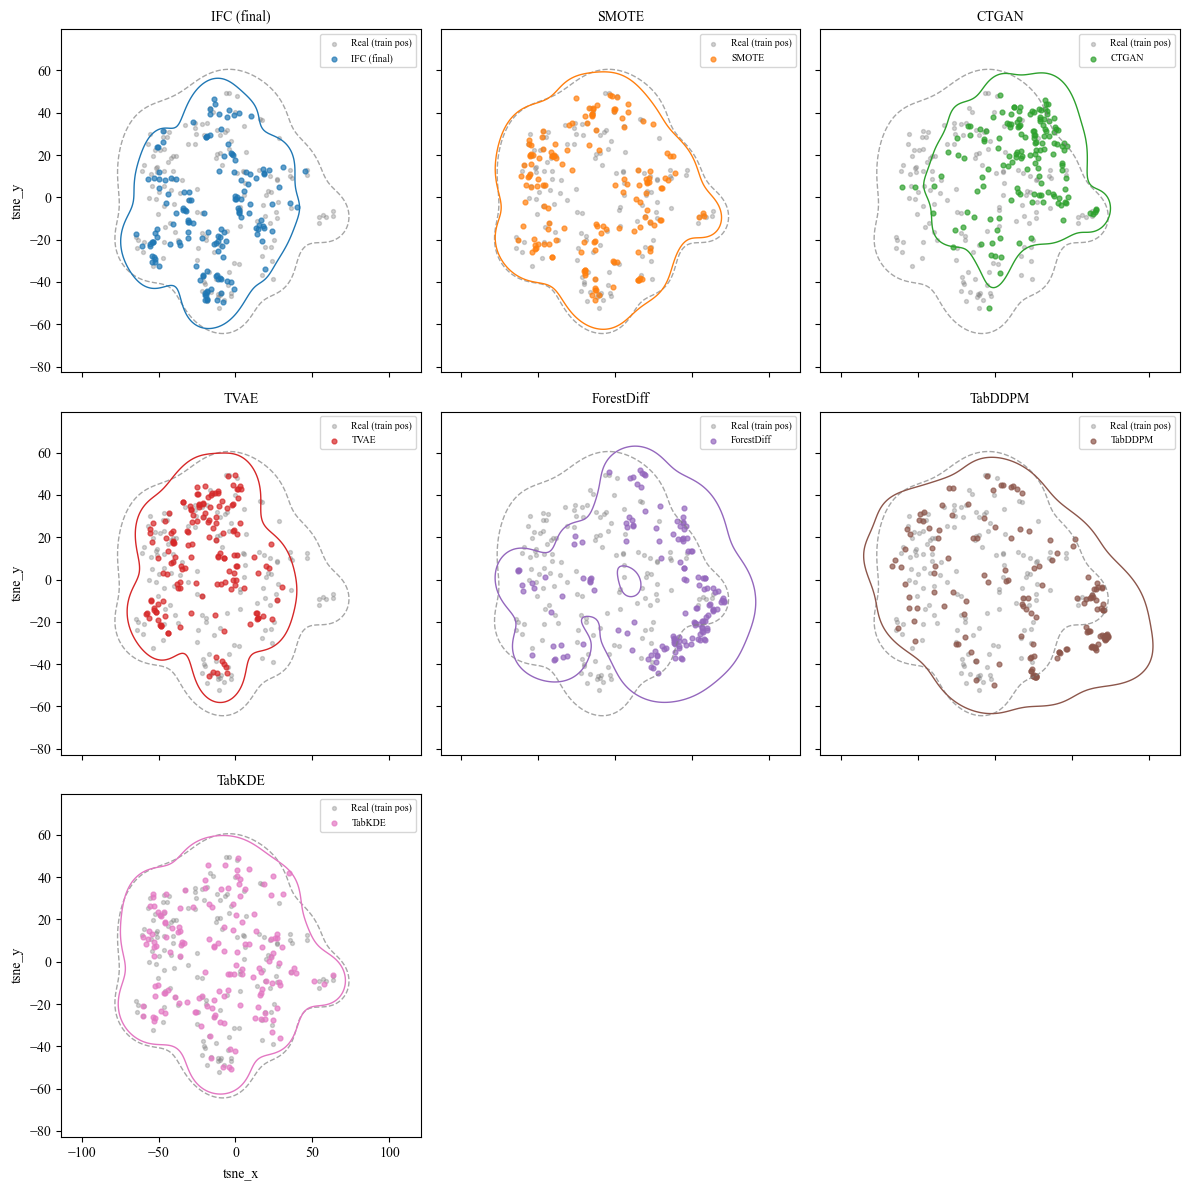

In [8]:
import importlib
import process.ifc_fidelity_analysis
importlib.reload(process.ifc_fidelity_analysis)
from utils.common import load_json

from process.ifc_fidelity_analysis import *

methods_to_show = {
    "IFC (final)": {"method": "smote_ft", "mix_ratio": "mix_55_532", "stage_depth": 3, "stage": "__fidelity__"},
    "SMOTE": {"method": "smote", "stage": "__fidelity__"},
    "CTGAN": {"method": "ctgan", "stage": "__fidelity__"},
    "TVAE": {"method": "tvae", "stage": "__fidelity__"},
    "ForestDiff": {"method": "forestdiffusion", "stage": "__fidelity__"},
    "TabDDPM": {"method": "tabddpm", "stage": "__fidelity__"},
    "TabKDE": {"method": "tabkde", "stage": "__fidelity__"},
}

ctx = load_dataset_context("framingham", all_results, orig_table,
                            root / "data/datasets_info.json", load_json_fn=load_json)
group_specs = build_group_specs(ctx, artifacts_table, methods_to_show)

fig1 = plot_correlation_grid(ctx, group_specs, title=f"{ctx.dataset}: Kendall correlation")
combined = build_combined_embedding(ctx, group_specs)
fig2 = render_subplot_grid(combined, [l for l, _ in group_specs])

In [ ]:
# IFC自身完整流程演化(需要单独构造,包含v0/VAE-only+VAE+FT+v1/v2/v3+final)
pipeline_specs = {
    "VAE only": {"method": "none_noft", "stage": "v0"},
    "VAE + FT": {"method": "none_ft", "stage": "__all_clusters__"},
    "Self-loop v1": {"method": "smote_ft", "mix_ratio": "mix_55_532", "stage_depth": 3, "stage": "v1"},
    "Self-loop v2": {"method": "smote_ft", "mix_ratio": "mix_55_532", "stage_depth": 3, "stage": "v2"},
    "Self-loop v3": {"method": "smote_ft", "mix_ratio": "mix_55_532", "stage_depth": 3, "stage": "v3"},
    "IFC (final)": {"method": "smote_ft", "mix_ratio": "mix_55_532", "stage_depth": 3, "stage": "__fidelity__"},
}
pipeline_frames = build_group_specs(ctx, artifacts_table, pipeline_specs)
evolution_table = build_stage_evolution_table(ctx, pipeline_frames)


,stage,column,type,skewness,n_peaks,js_divergence,category_coverage
0,Real,age,numeric,-0.250,1.0,NaN,NaN
1,Real,cigsPerDay,numeric,0.913,2.0,NaN,NaN
2,Real,totChol,numeric,1.461,1.0,NaN,NaN
3,Real,sysBP,numeric,0.788,1.0,NaN,NaN
4,Real,diaBP,numeric,0.475,1.0,NaN,NaN
...,...,...,...,...,...,...,...
93,IFC (final),currentSmoker,categorical,NaN,NaN,0.006,1.0
94,IFC (final),BPMeds,categorical,NaN,NaN,0.077,1.0
95,IFC (final),prevalentStroke,categorical,NaN,NaN,0.037,1.0
96,IFC (final),prevalentHyp,categorical,NaN,NaN,0.055,1.0
